# Stimulus omission responses at different flash rates

This notebook generates the plots for Supplementary Figure 12-16, which showcase the omission stimulus responses of the model at different flash rates, and the unit properties that relate to this

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from retina import analysis, train
from matplotlib.patches import Rectangle

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.abspath(".") if os.path.exists("setup.py") else os.path.abspath("..")

osr_query_set = analysis.OSRQuerySet(root, ablate_recurrence=False)
osr_query_set_ablated = analysis.OSRQuerySet(root, ablate_recurrence=True)


In [3]:
def get_last_flash_onset(ors_query, units='ms'):
    flash_train = ors_query.flash_clip
    indexes_of_negatives = np.where(np.diff(flash_train) < 0)[0]
    last_flash_onset = indexes_of_negatives[-1] + 1  

    if units == 'ms':
        return last_flash_onset * 4.333
    elif units == 'time_bins':
        return last_flash_onset
    else:
        raise ValueError("units must be either 'ms' or 'time_bins'")

def plot_osr(ors_query, intesity_ax, max_r, idx, d, firing_ax, plot_latency=False, input_current=False):

    last_flash_onset = get_last_flash_onset(ors_query,'time_bins')
    
    intesity_ax.plot(ors_query.flash_clip, c="black", linewidth=2)
    intesity_ax.spines["top"].set_visible(False)
    intesity_ax.spines["right"].set_visible(False)
    intesity_ax.spines["bottom"].set_visible(False)
    intesity_ax.spines["left"].set_linewidth(2)
    
    fs = 14
    intesity_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    intesity_ax.set_yticks([0, 1])
    intesity_ax.set_xlim([0, len(ors_query.flash_clip)])
    intesity_ax.set_xticks([])
    intesity_ax.set_xticklabels([])
    intesity_ax.set_xlabel("")
    
    firing_ax.plot([388-d, 388-d], [0, 1], "--", c="black", linewidth=2)

    color = '#1f77b4'
    if input_current:
        input_current = ors_query.smooth_input_current[idx]
        firing_ax.plot(input_current, linewidth=3, c=color)
    else:
        firing_rate = ors_query.firing_rate[idx]
        firing_ax.plot(firing_rate, linewidth=3, c=color)

    firing_ax.set_xticks([0, 36, 36+120, 36+2*120, 36+3*120])
    firing_ax.set_xticklabels(["", "0", "0.5", "1.0", "1.5"]) 
    
    firing_ax.spines["top"].set_visible(False)
    firing_ax.spines["right"].set_visible(False)
    firing_ax.spines["bottom"].set_linewidth(2)
    firing_ax.spines["left"].set_linewidth(2)
    firing_ax.set_xlim([0, len(ors_query.flash_clip)])
    firing_ax.set_ylim([0., 1.1*max_r])
    firing_ax.set_yticks([0, max_r])
    firing_ax.set_yticklabels(["0", f"{int(max_r * (240))}"])
    firing_ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.set_xlabel("Time (s)", fontsize=fs, labelpad=8)
    firing_ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=10)
    
    return last_flash_onset*4.333

## 12Hz OSR

In [4]:
ors_query_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12)

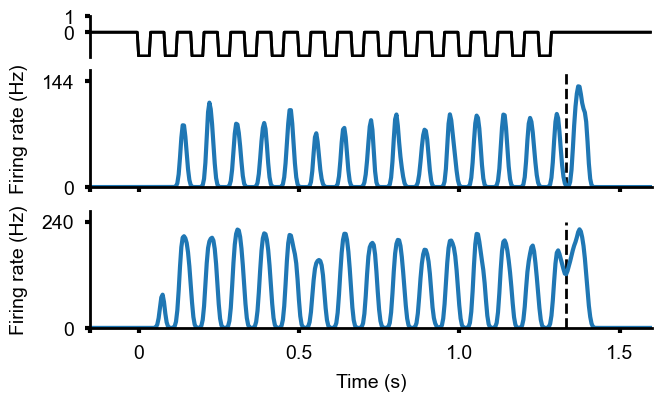

In [5]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1-7
plot_osr(ors_query_12hz, intesity_ax, 0.6, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_12hz, intesity_ax, 1, 349, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/12hz_new.svg", format="svg", transparent=False, bbox_inches="tight")

## 16Hz OSR

In [6]:
ors_query_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16)

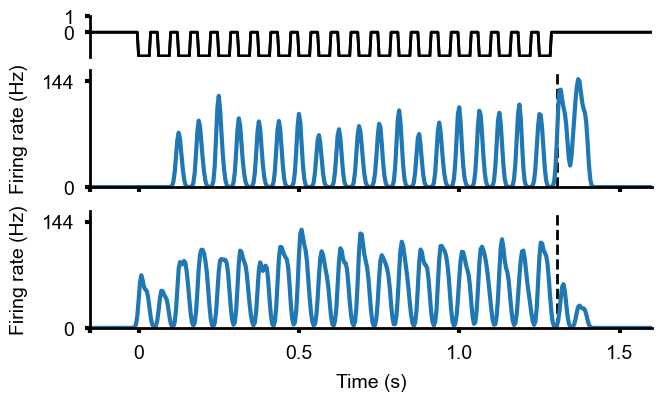

In [7]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1
plot_osr(ors_query_16hz, intesity_ax, 0.6, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_16hz, intesity_ax, 0.6, 393, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 8Hz OSR

In [8]:
osr_query_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8)

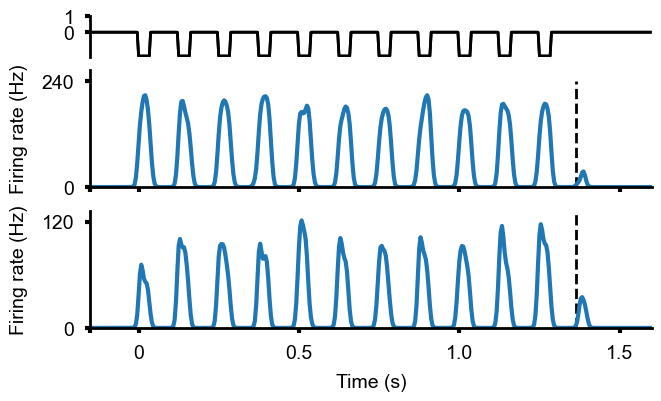

In [9]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-30+9+1+1
plot_osr(osr_query_8hz, intesity_ax, 1, 253, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(osr_query_8hz, intesity_ax, 0.5, 393, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/8hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 16 Hz with middle of the sequence omission

In [10]:
ors_query_mid_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=True)

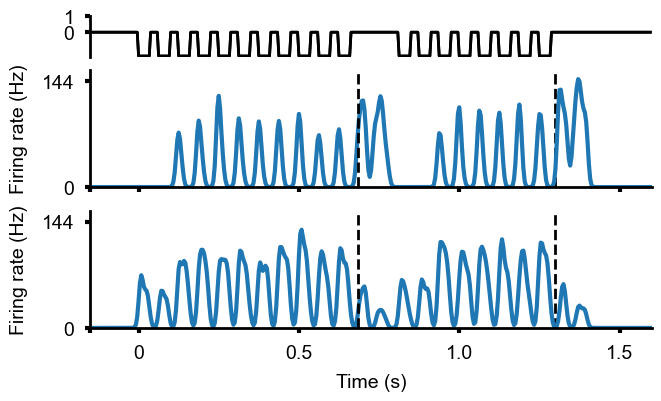

In [11]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1+1
x=200
plot_osr(ors_query_mid_16hz, intesity_ax, 0.6, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_mid_16hz, intesity_ax, 0.6, 393, d, firing2_ax)
firing1_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
firing2_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
plt.savefig(f"{root}/figures/supp/mid_16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## Response latency to period relationship

In [12]:
osr_query_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8, middle_omission=False)
osr_query_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12, middle_omission=False)
osr_query_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=False)
osr_query_20hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=20, middle_omission=False)
osr_query_ablate_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_20hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=20, middle_omission=False, ablate_recurrence=True)
osr_query_mid_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=True)
osr_query_8hz_enc = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8, middle_omission=False, pred_offset=0)
osr_query_12hz_enc = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12, middle_omission=False, pred_offset=0)
osr_query_16hz_enc = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=False, pred_offset=0)
osr_query_20hz_enc = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=20, middle_omission=False, pred_offset=0)

In [13]:
def plot_spatiotemporal_rf(strf, fig, spec):
    strf = strf.cpu().detach()
    maxv = strf.abs().max()
    
    for j in range(3, len(strf)):
        ax = plt.Subplot(fig, spec[0, j])
        fig.add_subplot(ax)
        im = ax.imshow(strf[j], cmap="bwr", vmin=-maxv, vmax=maxv)
        ax.axis("off")
        
def extract_component_matrices(W, index: int):
    if not (0 <= index < W.shape[0]):
        raise IndexError(f"Index {index} is out of bounds for first dimension of size {W.shape[0]}")
    
    return W[index].squeeze(0)  

def signed_biphasic_score(signal):
    signal = np.asarray(signal)

    if np.all(signal == signal[0]):
        return 0.0  

    min_idx = np.argmin(signal)
    if min_idx < len(signal) - 1:
        max_after_min = np.max(signal[min_idx + 1:])#signal[-1]
        initial_drop = signal[0] - signal[min_idx]
        recovery = max_after_min - signal[min_idx]
        if initial_drop > 0 and recovery > 0:
            return recovery / initial_drop

    max_idx = np.argmax(signal)
    if max_idx < len(signal) - 1:
        min_after_max = np.min(signal[max_idx + 1:])#signal[-1]
        initial_rise = signal[max_idx] - signal[0]
        fall = signal[max_idx] - min_after_max
        if initial_rise > 0 and fall > 0:
            return -fall / initial_rise

    return 0.0


enc_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_0_8")
pred_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")

W_enc = enc_model._encoder_weight
W = pred_model._encoder_weight

In [14]:
plot_figs = False

lfp_list = np.full((400, 4), np.nan)
lfp_list = np.full((400, 4), np.nan)
osr_list = np.full((400, 4), np.nan)
lfp_list_ablate = np.full((400, 4), np.nan)
lfp_list_ablate = np.full((400, 4), np.nan)
osr_list_ablate = np.full((400, 4), np.nan)
ffp_list_input = np.full((400, 4), np.nan)
lfp_list_input = np.full((400, 4), np.nan)
osr_list_input = np.full((400, 4), np.nan)

peak_delay = 2
match_firing_version = False
valid_units = 0
valid_units_ablate = 0
valid_units_input = 0
valid_units_12Hz = 0
valid_units_ablate_12Hz = 0
valid_units_enc = 0
valid_units_12Hz_enc = 0

sbs_list = []
abs_sbs_list = []
valid_flags = []

sbs_list_enc = []
abs_sbs_list_enc = []
valid_flags_enc = []

for n in range(400):
    if (n in osr_query_8hz.responsive_idx) or (n in osr_query_12hz.responsive_idx) or (n in osr_query_8hz.responsive_idx) and (n in osr_query_8hz.responsive_idx):
        x=200
        
        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(50, 2))
            spec = gridspec.GridSpec(nrows=1, ncols=50, figure=fig)
            plot_spatiotemporal_rf(extract_component_matrices(W,n),fig,spec)
            plt.show()
        
        unit_W = extract_component_matrices(W, n)  

        time_series = unit_W.sum(dim=(1, 2))  
        
        ts_np = time_series.detach().cpu().numpy()
        sbs = signed_biphasic_score(ts_np[::-1])
        abs_sbs = signed_biphasic_score(np.abs(ts_np)[::-1])

        if plot_figs:
            plt.figure(figsize=(8, 3))
            plt.plot(time_series.detach().cpu().numpy())
            plt.title(f"Sum of spatial weights over time (Unit {n}), signed biphasic score {sbs}")
            plt.xlabel("Time index")
            plt.ylabel("Sum of weights")
            plt.tight_layout()
            plt.show()

        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
            spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
            intesity1_ax = fig.add_subplot(spec[0])
            plt.title('Unit: n=%i' %n)
            firing1_ax = fig.add_subplot(spec[1]) 
            d=44-15+9+1+4-20
            last_flash_onset = plot_osr(osr_query_8hz, intesity1_ax, 1, n, d, firing1_ax)            
        else:
            last_flash_onset = get_last_flash_onset(osr_query_8hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_8hz.firing_rate[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
            
        if plot_figs:
            intesity2_ax = fig.add_subplot(spec[2])
            firing2_ax = fig.add_subplot(spec[3]) 
            d=44-15+9+1+3-10
            last_flash_onset = plot_osr(osr_query_12hz, intesity2_ax, 1, n, d, firing2_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_12hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_12hz.firing_rate[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            valid_units_12Hz += 1
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
            
        if plot_figs:   
            intesity3_ax = fig.add_subplot(spec[4])
            firing3_ax = fig.add_subplot(spec[5]) 
            d=44-15+9+1+2-4
            last_flash_onset = plot_osr(osr_query_16hz, intesity3_ax, 1, n, d, firing3_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_16hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_16hz.firing_rate[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
            
        if plot_figs:
            intesity4_ax = fig.add_subplot(spec[6])
            firing4_ax = fig.add_subplot(spec[7]) 
            d=44-15+9+1+1
            last_flash_onset = plot_osr(osr_query_20hz, intesity4_ax, 1, n, d, firing4_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_20hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_20hz.firing_rate[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
            
        if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
            lfp_list[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
            osr_list[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
            isvalid = True
            valid_units += 1
        else:
            isvalid = False
            
        sbs_list.append(sbs)
        abs_sbs_list.append(abs_sbs)
        valid_flags.append(isvalid) 


        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
            spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
            intesity1_ax = fig.add_subplot(spec[0])
            plt.title('Unit: n=%i' %n)
            firing1_ax = fig.add_subplot(spec[1]) 
            d=44-15+9+1+4-20
            last_flash_onset = plot_osr(osr_query_ablate_8hz, intesity1_ax, 1, n, d, firing1_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_ablate_8hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_8hz.firing_rate[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
            
        if plot_figs:    
            intesity2_ax = fig.add_subplot(spec[2])
            firing2_ax = fig.add_subplot(spec[3]) 
            d=44-15+9+1+3-10
            last_flash_onset = plot_osr(osr_query_ablate_12hz, intesity2_ax, 1, n, d, firing2_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_ablate_12hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_12hz.firing_rate[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            valid_units_ablate_12Hz += 1
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
        
        if plot_figs:
            intesity3_ax = fig.add_subplot(spec[4])
            firing3_ax = fig.add_subplot(spec[5]) 
            d=44-15+9+1+2-4
            last_flash_onset = plot_osr(osr_query_ablate_16hz, intesity3_ax, 1, n, d, firing3_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_ablate_16hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_16hz.firing_rate[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
        
        if plot_figs:
            intesity4_ax = fig.add_subplot(spec[6])
            firing4_ax = fig.add_subplot(spec[7]) 
            d=44-15+9+1+1
            last_flash_onset = plot_osr(osr_query_ablate_20hz, intesity4_ax, 1, n, d, firing4_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_ablate_20hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_20hz.firing_rate[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
            
        if match_firing_version:
            if isvalid:
                lfp_list_ablate[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_ablate[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
        else:
            if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
                lfp_list_ablate[valid_units_ablate,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_ablate[valid_units_ablate,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
                valid_units_ablate += 1
            

        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
            spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
            intesity1_ax = fig.add_subplot(spec[0])
            plt.title('Unit: n=%i' %n)
            firing1_ax = fig.add_subplot(spec[1]) 
            d=44-15+9+1+4-20
            last_flash_onset = plot_osr(osr_query_8hz, intesity1_ax, 1, n, d, firing1_ax, input_current=True)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_8hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_8hz.smooth_input_current[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
        
        if plot_figs:
            intesity2_ax = fig.add_subplot(spec[2])
            firing2_ax = fig.add_subplot(spec[3]) 
            d=44-15+9+1+3-10
            last_flash_onset = plot_osr(osr_query_12hz, intesity2_ax, 1, n, d, firing2_ax, input_current=True)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_12hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_12hz.smooth_input_current[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
            
        if plot_figs:
            intesity3_ax = fig.add_subplot(spec[4])
            firing3_ax = fig.add_subplot(spec[5]) 
            d=44-15+9+1+2-4
            last_flash_onset = plot_osr(osr_query_16hz, intesity3_ax, 1, n, d, firing3_ax, input_current=True)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_16hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_16hz.smooth_input_current[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
            
        if plot_figs:
            intesity4_ax = fig.add_subplot(spec[6])
            firing4_ax = fig.add_subplot(spec[7]) 
            d=44-15+9+1+1
            last_flash_onset = plot_osr(osr_query_20hz, intesity4_ax, 1, n, d, firing4_ax, input_current=True)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_20hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_20hz.smooth_input_current[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
            
        if match_firing_version:
            if isvalid:
                lfp_list_input[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_input[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
        else:
            if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
                lfp_list_input[valid_units_input,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_input[valid_units_input,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
                valid_units_input += 1
                
    if (n in osr_query_8hz_enc.responsive_idx) or (n in osr_query_12hz_enc.responsive_idx) or (n in osr_query_8hz_enc.responsive_idx) and (n in osr_query_8hz_enc.responsive_idx):
        

        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(50, 2))
            spec = gridspec.GridSpec(nrows=1, ncols=50, figure=fig)
            plot_spatiotemporal_rf(extract_component_matrices(W_enc,n),fig,spec)
            plt.show()
        
        unit_W_enc = extract_component_matrices(W_enc, n)  

        time_series = unit_W_enc.sum(dim=(1, 2)) 
        
        ts_np_enc = time_series.detach().cpu().numpy()
        sbs_enc = signed_biphasic_score(ts_np_enc[::-1])
        abs_sbs_enc = signed_biphasic_score(np.abs(ts_np_enc)[::-1])

        if plot_figs:
            plt.figure(figsize=(8, 3))
            plt.plot(time_series.detach().cpu().numpy(), color='green')
            plt.title(f"Sum of spatial weights over time (Unit {n}), signed biphasic score {sbs_enc}")
            plt.xlabel("Time index")
            plt.ylabel("Sum of weights")
            plt.tight_layout()
            plt.show()


        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
            spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
            intesity1_ax = fig.add_subplot(spec[0])
            plt.title('Unit: n=%i' %n)
            firing1_ax = fig.add_subplot(spec[1]) 
            d=44-15+9+1+4-20
            last_flash_onset = plot_osr(osr_query_8hz_enc, intesity1_ax, 1, n, d, firing1_ax)            
        else:
            last_flash_onset = get_last_flash_onset(osr_query_8hz_enc,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_8hz_enc.firing_rate[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
            
        if plot_figs:
            intesity2_ax = fig.add_subplot(spec[2])
            firing2_ax = fig.add_subplot(spec[3]) 
            d=44-15+9+1+3-10
            last_flash_onset = plot_osr(osr_query_12hz_enc, intesity2_ax, 1, n, d, firing2_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_12hz_enc,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_12hz_enc.firing_rate[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            valid_units_12Hz_enc += 1
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
            
        if plot_figs:   
            intesity3_ax = fig.add_subplot(spec[4])
            firing3_ax = fig.add_subplot(spec[5]) 
            d=44-15+9+1+2-4
            last_flash_onset = plot_osr(osr_query_16hz_enc, intesity3_ax, 1, n, d, firing3_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_16hz_enc,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_16hz_enc.firing_rate[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
            
        if plot_figs:
            intesity4_ax = fig.add_subplot(spec[6])
            firing4_ax = fig.add_subplot(spec[7]) 
            d=44-15+9+1+1
            last_flash_onset = plot_osr(osr_query_20hz_enc, intesity4_ax, 1, n, d, firing4_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_20hz_enc,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_20hz_enc.firing_rate[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
            
        if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
            lfp_list[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
            osr_list[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
            isvalid_enc = True
            valid_units_enc += 1
        else:
            isvalid_enc = False
            

        sbs_list_enc.append(sbs_enc)
        abs_sbs_list_enc.append(abs_sbs_enc)
        valid_flags_enc.append(isvalid_enc) 
    

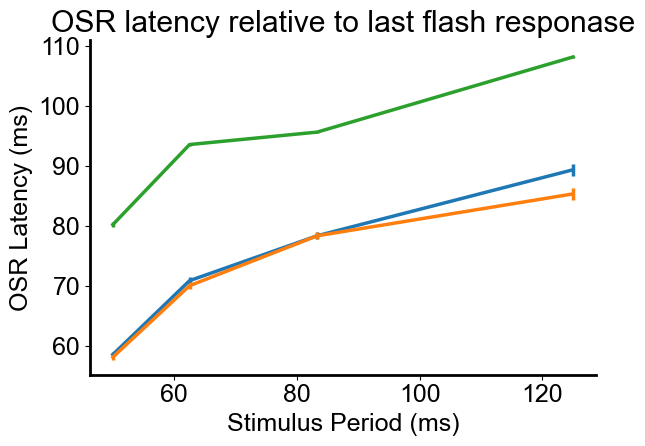

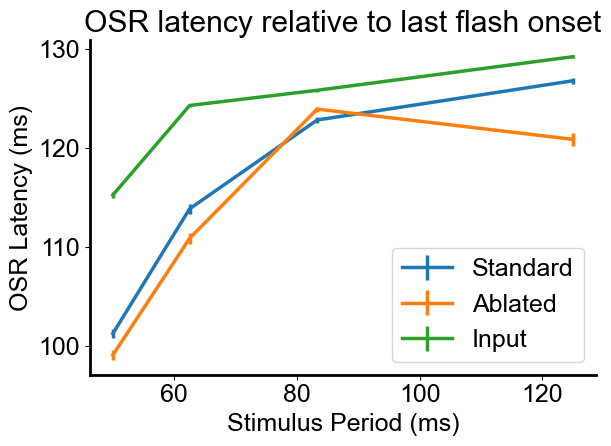

In [15]:
plt.rcParams.update({
    'font.size': 18,          
    'lines.linewidth': 2.5,   
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2.0    
})

last_flash_onset1 = get_last_flash_onset(osr_query_8hz, 'ms')
last_flash_onset2 = get_last_flash_onset(osr_query_12hz, 'ms')
last_flash_onset3 = get_last_flash_onset(osr_query_16hz, 'ms')
last_flash_onset4 = get_last_flash_onset(osr_query_20hz, 'ms')
lfo = [last_flash_onset4, last_flash_onset3, last_flash_onset2, last_flash_onset1]

lfp_list = lfp_list[:valid_units,:]
osr_list = osr_list[:valid_units,:]


if match_firing_version:
    lfp_list_ablate = lfp_list_ablate[:valid_units,:]
    osr_list_ablate = osr_list_ablate[:valid_units,:]
    lfp_list_input = lfp_list_input[:valid_units,:]
    osr_list_input = osr_list_input[:valid_units,:]
else:
    lfp_list_ablate = lfp_list_ablate[:valid_units_ablate,:]
    osr_list_ablate = osr_list_ablate[:valid_units_ablate,:]
    lfp_list_input = lfp_list_input[:valid_units_input,:]
    osr_list_input = osr_list_input[:valid_units_input,:]

    
plt.figure()
latencies = np.fliplr(osr_list - lfp_list)*4.333
meanlatency = np.nanmean(latencies,axis=0)
semlatency = np.nanstd(latencies,axis=0)/np.sum(~np.isnan(latencies),axis=0)
periods = np.array([50, 62.5, 83.3, 125])
plt.errorbar(periods,meanlatency,semlatency)

latencies_ablate = np.fliplr(osr_list_ablate - lfp_list_ablate)*4.333
meanlatency_ablate = np.nanmean(latencies_ablate,axis=0)
semlatency_ablate = np.nanstd(latencies_ablate,axis=0)/np.sum(~np.isnan(latencies_ablate),axis=0)
plt.errorbar(periods,meanlatency_ablate,semlatency_ablate)

latencies_input = np.fliplr(osr_list_input - lfp_list_input)*4.333
meanlatency_input = np.nanmean(latencies_input,axis=0)
semlatency_input = np.nanstd(latencies_input,axis=0)/np.sum(~np.isnan(latencies_input),axis=0)
plt.errorbar(periods,meanlatency_input,semlatency_input)
plt.xlabel("Stimulus Period (ms)")
plt.ylabel("OSR Latency (ms)")
plt.title("OSR latency relative to last flash responase")
plt.tight_layout()


plt.figure()
latencies = np.fliplr(osr_list - last_flash_onset1/4.333)*4.333
meanlatency = np.nanmean(latencies,axis=0)
semlatency = np.nanstd(latencies,axis=0)/np.sum(~np.isnan(latencies),axis=0)
periods = np.array([50, 62.5, 83.3, 125])
plt.errorbar(periods,meanlatency,semlatency)

latencies_ablate = np.fliplr(osr_list_ablate - last_flash_onset1/4.333)*4.333
meanlatency_ablate = np.nanmean(latencies_ablate,axis=0)
semlatency_ablate = np.nanstd(latencies_ablate,axis=0)/np.sum(~np.isnan(latencies_ablate),axis=0)
plt.errorbar(periods,meanlatency_ablate,semlatency_ablate)

latencies_input = np.fliplr(osr_list_input  - last_flash_onset1/4.333)*4.333
meanlatency_input = np.nanmean(latencies_input,axis=0)
semlatency_input = np.nanstd(latencies_input,axis=0)/np.sum(~np.isnan(latencies_input),axis=0)
plt.errorbar(periods,meanlatency_input,semlatency_input)
plt.xlabel("Stimulus Period (ms)")
plt.ylabel("OSR Latency (ms)")
plt.legend(["Standard", "Ablated", "Input"], loc="best")
plt.title("OSR latency relative to last flash onset")
plt.tight_layout()

fig.savefig(f"{root}/figures/supp/OSR_latency_new.svg", transparent=False, bbox_inches="tight")

In [16]:
active_units = 287
print('Percentage of units with valid OSR at any dark-flash rate')
print(100*valid_units/active_units)
print('Percentage of units with valid OSR at any dark-flash rate with ablated recurrency')
print(100*valid_units_ablate/active_units)
print('Percentage of units with valid OSR at 12Hz dark-flash rate')
print(100*valid_units_12Hz/active_units)
print('Percentage of units with valid OSR at 12Hz dark-flash rate with ablated recurrency')
print(100*valid_units_ablate_12Hz/active_units)

Percentage of units with valid OSR at any dark-flash rate
19.51219512195122
Percentage of units with valid OSR at any dark-flash rate with ablated recurrency
19.860627177700348
Percentage of units with valid OSR at 12Hz dark-flash rate
16.027874564459932
Percentage of units with valid OSR at 12Hz dark-flash rate with ablated recurrency
16.37630662020906


## Inspection of spatiotemporal RFs of OSR units

In [17]:
ors_query = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300)

In [18]:
enc_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_0_8")
pred_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")
enc_rf_query = analysis.RFQuery(root, enc_model)
pred_rf_query = analysis.RFQuery(root, pred_model)

INFO:util:Processing batch 0 out of 4...


INFO:util:Processing batch 1 out of 4...


INFO:util:Processing batch 2 out of 4...


INFO:util:Processing batch 3 out of 4...


INFO:gaussian:CC criteria exclusion 400


...

INFO:util:Processing batch 2 out of 4...


INFO:util:Processing batch 3 out of 4...


INFO:gaussian:CC criteria exclusion 224


INFO:gaussian:Location criteria exclusion 38


INFO:gaussian:Envelope criteria exclusion 12


In [19]:
def plot_spatiotemporal_rf(strf, i, subspec, fig):
    strf = strf.cpu().detach()
    maxv = strf.abs().max()
    
    for j in range(3, len(strf)):
        ax = plt.Subplot(fig, subspec[i, j])
        fig.add_subplot(ax)
        im = ax.imshow(strf[j], cmap="bwr", vmin=-maxv, vmax=maxv)
        ax.add_patch(Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            fill=False,
            edgecolor="0.5",
            linewidth=0.6,
            zorder=10,
            clip_on=False,
        ))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

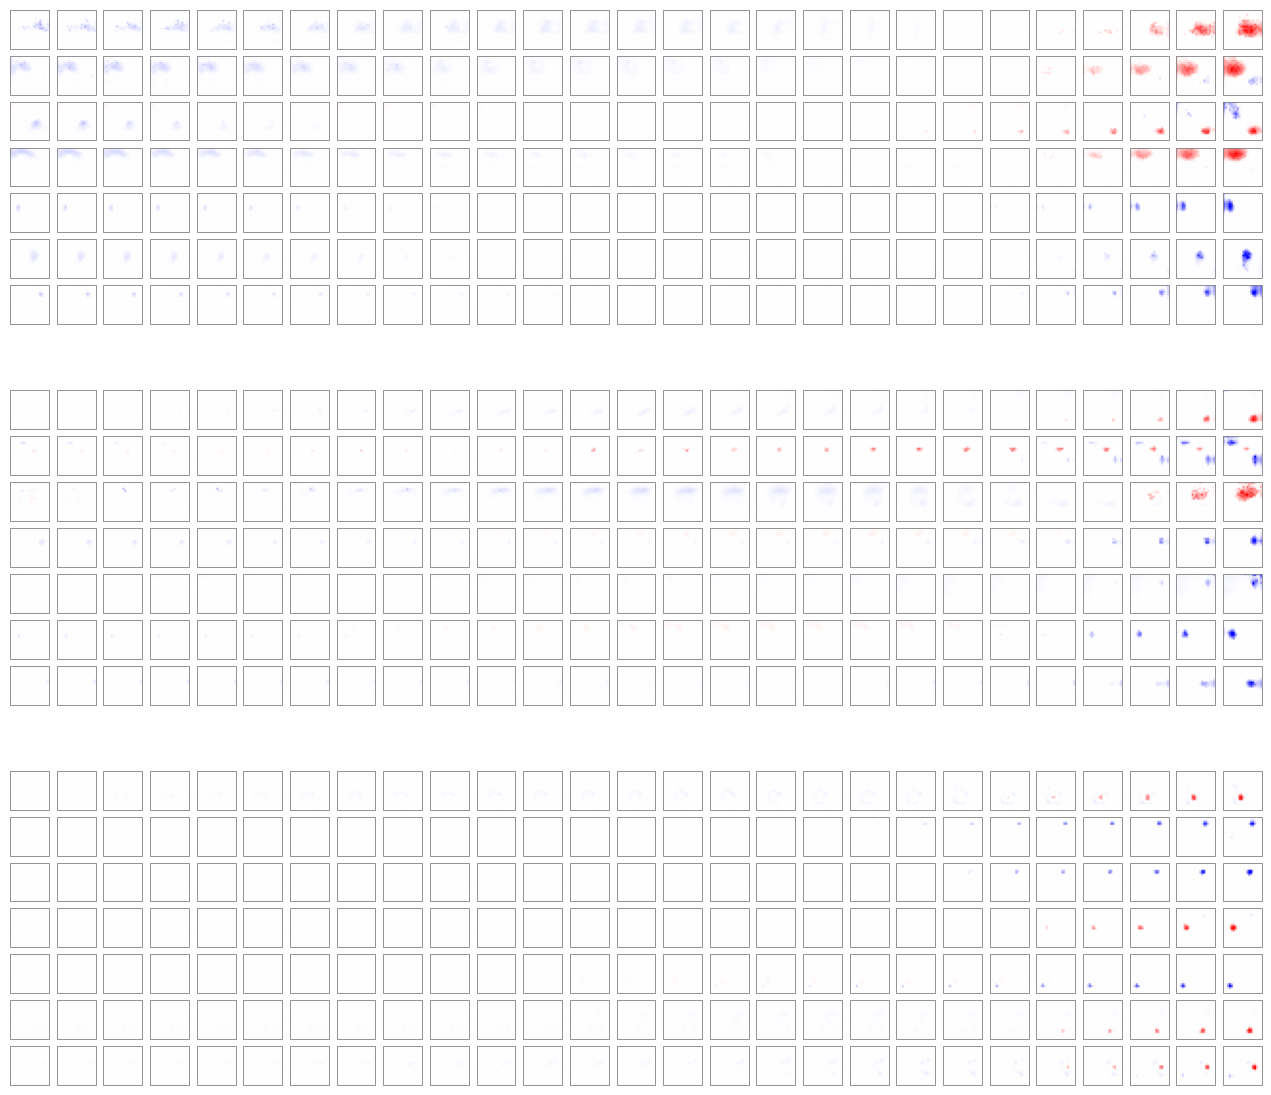

In [20]:
W = pred_model._encoder_weight
W2 = enc_model._encoder_weight

l = 30
fig = plt.figure(constrained_layout=True, figsize=(30, 14))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[1, 1, 1], hspace=0.2)
top_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[0], hspace=0.1)
mid_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[1], hspace=0.1)
bottom_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[2], hspace=0.1)

plot_spatiotemporal_rf(extract_component_matrices(W,8), 0, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,17), 1, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,21), 2, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,29), 3, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,95), 4, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,151), 5, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,381), 6, top_spec, fig)

plot_spatiotemporal_rf(extract_component_matrices(W,247), 0, mid_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,185), 1, mid_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,237), 2, mid_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,14), 3, mid_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,24), 4, mid_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,41), 5, mid_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,395), 6, mid_spec, fig)


plot_spatiotemporal_rf(extract_component_matrices(W2, 2), 0, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 93), 1, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 264), 2, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 56), 3, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 136), 4, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 89), 5, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 283), 6, bottom_spec, fig)

fig.savefig(f"{root}/figures/supp/OSR_W_new.svg", transparent=False, bbox_inches="tight")

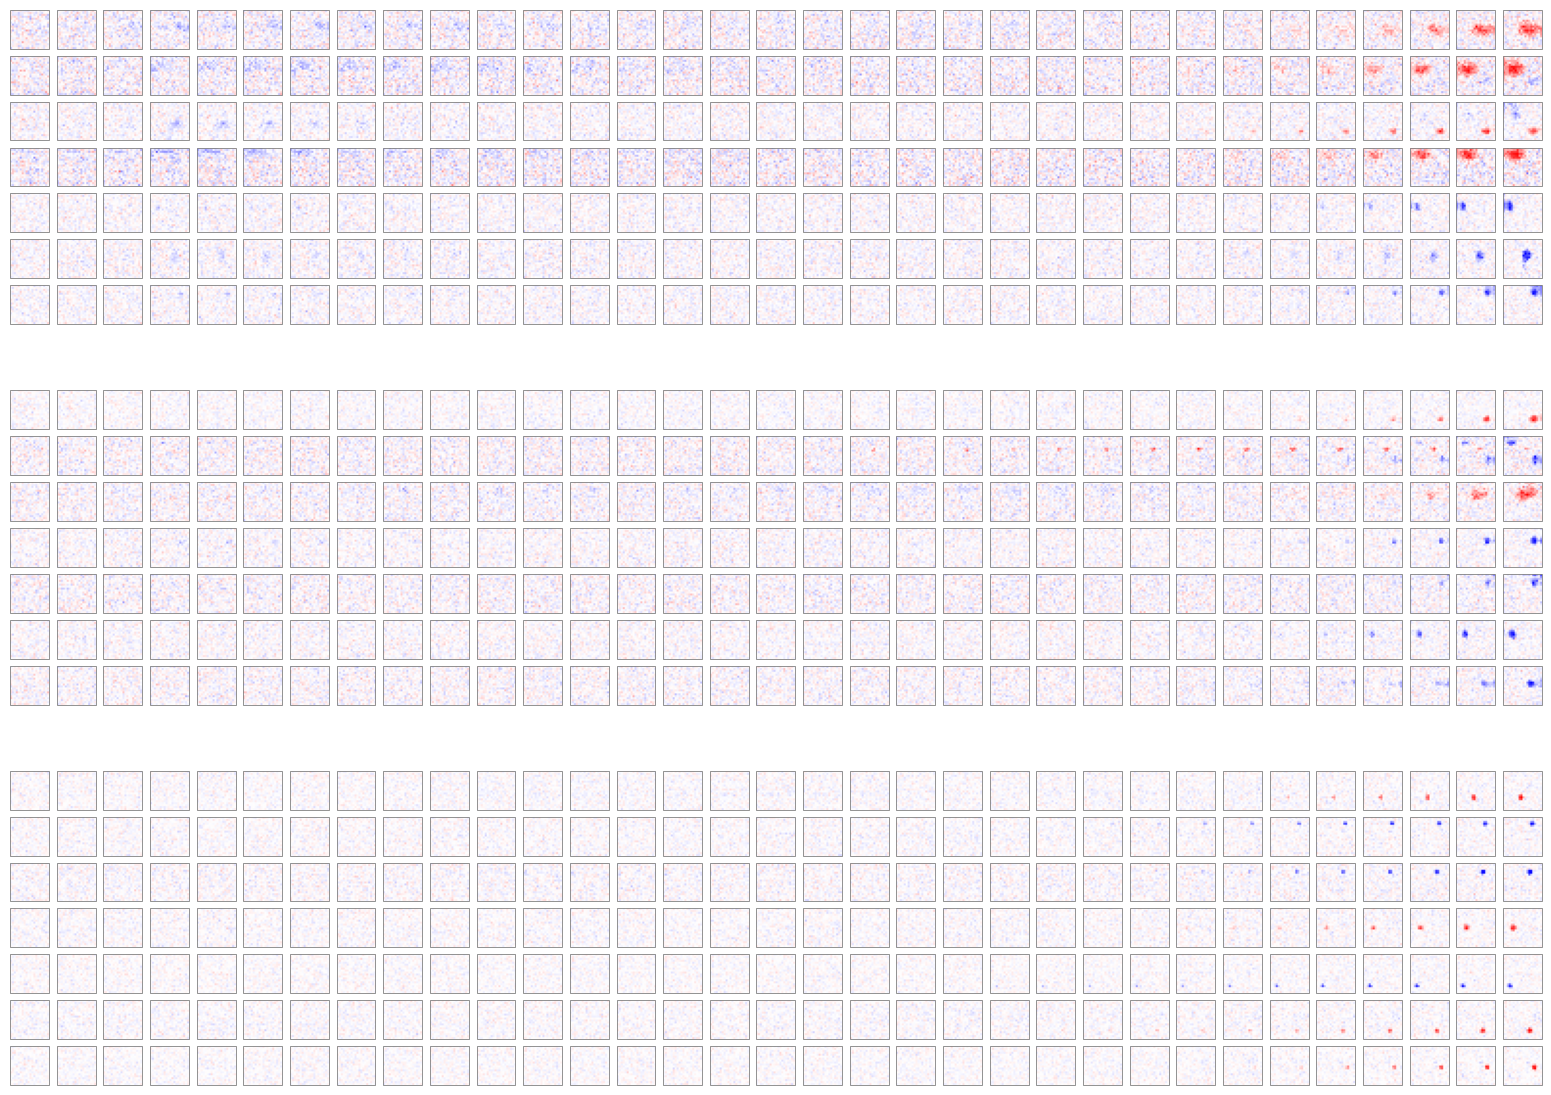

In [21]:
l = 30
fig = plt.figure(constrained_layout=True, figsize=(30, 14))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[1, 1, 1], hspace=0.2)
top_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[0], hspace=0.1)
mid_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[1], hspace=0.1)
bottom_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[2], hspace=0.1)

plot_spatiotemporal_rf(pred_rf_query.og_strfs[8, :], 0, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[17, :], 1, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[21, :], 2, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[29, :], 3, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[95, :], 4, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[151, :], 5, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[381, :], 6, top_spec, fig)

plot_spatiotemporal_rf(pred_rf_query.og_strfs[247, :], 0, mid_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[185, :], 1, mid_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[237, :], 2, mid_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[14, :], 3, mid_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[24, :], 4, mid_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[41, :], 5, mid_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[395, :], 6, mid_spec, fig)

plot_spatiotemporal_rf(enc_rf_query.og_strfs[2, :], 0, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[93, :], 1, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[264, :], 2, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[56, :], 3, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[136, :], 4, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[89, :], 5, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[283, :], 6, bottom_spec, fig)

fig.savefig(f"{root}/figures/supp/OSR_RFs_new.svg", transparent=False, bbox_inches="tight")

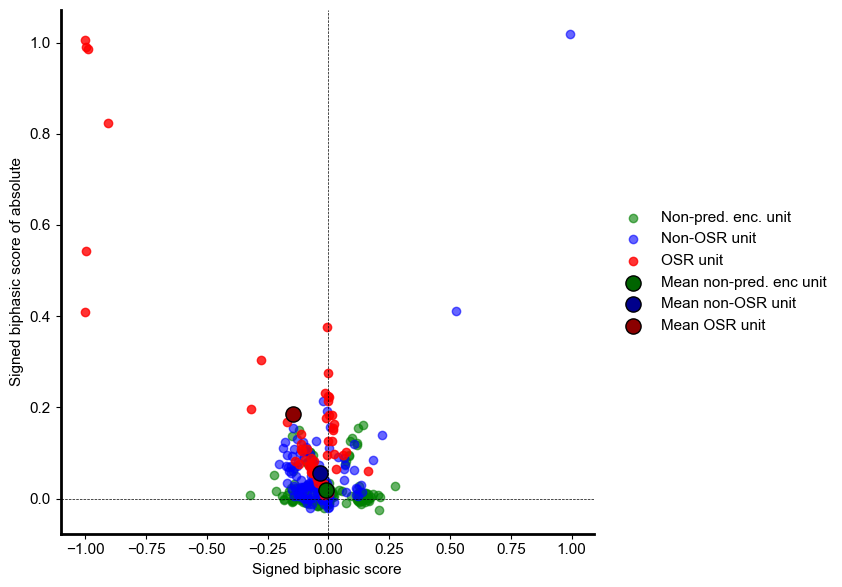

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

sbs_arr = np.array(sbs_list)
abs_sbs_arr = np.array(abs_sbs_list)
valid_flags_arr = np.array(valid_flags)
sbs_arr_enc = np.array(sbs_list_enc)
abs_sbs_arr_enc = np.array(abs_sbs_list_enc)
valid_flags_arr_enc = np.array(valid_flags_enc)

valid_mask = valid_flags_arr == True
invalid_mask = ~valid_mask
valid_mask_enc = np.ones_like(valid_flags_arr_enc, dtype=bool)
invalid_mask_enc = ~valid_mask_enc

sbs_arr = np.clip(sbs_arr, -1, 1)
abs_sbs_arr = np.clip(abs_sbs_arr, -1, 1)
sbs_arr_enc = np.clip(sbs_arr_enc, -1, 1)

jitter_scale = 0.01  
sbs_arr_jittered = sbs_arr + np.random.normal(0, jitter_scale, size=sbs_arr.shape)
abs_sbs_arr_jittered = abs_sbs_arr + np.random.normal(0, jitter_scale, size=abs_sbs_arr.shape)
sbs_arr_jittered_enc = sbs_arr_enc + np.random.normal(0, jitter_scale, size=sbs_arr_enc.shape)
abs_sbs_arr_jittered_enc = abs_sbs_arr_enc + np.random.normal(0, jitter_scale, size=abs_sbs_arr_enc.shape)

mean_valid = (np.mean(sbs_arr[valid_mask]), np.mean(abs_sbs_arr[valid_mask]))
mean_invalid = (np.mean(sbs_arr[invalid_mask]), np.mean(abs_sbs_arr[invalid_mask]))
mean_valid_enc = (np.mean(sbs_arr_enc[valid_mask_enc]), np.mean(abs_sbs_arr_enc[valid_mask_enc]))

plt.figure(figsize=(6, 6))
plt.scatter(sbs_arr_jittered_enc[valid_mask_enc], abs_sbs_arr_jittered_enc[valid_mask_enc],
            c='green', label='Non-pred. enc. unit', alpha=0.6)
plt.scatter(sbs_arr_jittered[invalid_mask], abs_sbs_arr_jittered[invalid_mask],
            c='blue', label='Non-OSR unit', alpha=0.6)
plt.scatter(sbs_arr_jittered[valid_mask], abs_sbs_arr_jittered[valid_mask],
            c='red', label='OSR unit', alpha=0.8)

plt.scatter(*mean_valid_enc, c='darkgreen', edgecolor='black', s=120, marker='o', label='Mean non-pred. enc unit')
plt.scatter(*mean_invalid, c='darkblue', edgecolor='black', s=120, marker='o', label='Mean non-OSR unit')
plt.scatter(*mean_valid, c='darkred', edgecolor='black', s=120, marker='o', label='Mean OSR unit')

plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(0, color='k', linestyle='--', linewidth=0.5)

plt.xlabel("Signed biphasic score")
plt.ylabel("Signed biphasic score of absolute")

fig = plt.gcf()
w, h = fig.get_size_inches()
fig.set_size_inches(w * 1.25, h, forward=True)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    frameon=False
)

plt.tight_layout()

fig = plt.gcf()
w, h = fig.get_size_inches()
fig.set_size_inches(w * 1.25, h, forward=True)

plt.show()

fig.savefig(f"{root}/figures/supp/OSR_W_biphasic_measure_new.svg", transparent=False, bbox_inches="tight")